# Cluster All Books
Applies the full clustering pipeline to the **AllBooks/** corpus (~98 books, 5 genres).
Books are loaded directly from `AllBooks/<genre>/`, cleaned, partitioned, and clustered
without reference to the 25 KnownBooks training set.

**Run order:** Standalone — does not depend on `BOW.ipynb` or `Book partitioner.ipynb`

**Algorithms:** K-Means · Divisive Hierarchical · LDA · GMM · SOM · DEC  
**Evaluations:** Silhouette · Cohen's Kappa · Topic Coherence (LDA)

In [ ]:
import os, re, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import silhouette_score, cohen_kappa_score
from sklearn.preprocessing import StandardScaler, normalize

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('words',     quiet=True)
from nltk.corpus import stopwords
from nltk.corpus import words as _nltk_words
ENGLISH_VOCAB = set(w.lower() for w in _nltk_words.words())

print(f'All imports successful. English vocabulary: {len(ENGLISH_VOCAB):,} words')

## Configuration

In [78]:
ALL_BOOKS_DIR       = 'AllBooks'
IMAGES_DIR          = 'images'
PARTITIONS_PER_BOOK = 200
WORDS_PER_PARTITION = 400
RANDOM_SEED         = 42
N_CLUSTERS          = 5
GENRES              = ['biography', 'fantasy', 'horror', 'romance', 'sci-fi']
os.makedirs(IMAGES_DIR, exist_ok=True)

# Project Gutenberg boilerplate strip patterns
_START = re.compile(r'\*{3}\s*START OF THE PROJECT GUTENBERG EBOOK[^\n]*\*{3}', re.IGNORECASE)
_END   = re.compile(r'\*{3}\s*END OF THE PROJECT GUTENBERG EBOOK[^\n]*\*{3}',   re.IGNORECASE)

def clean_gutenberg(raw):
    m = _START.search(raw)
    text = raw[m.end():] if m else raw
    m = _END.search(text)
    return text[:m.start()].strip() if m else text.strip()

print(f'AllBooks directory : {ALL_BOOKS_DIR}')
print(f'Partitions per book: {PARTITIONS_PER_BOOK} x {WORDS_PER_PARTITION} words')

AllBooks directory : AllBooks
Partitions per book: 200 x 400 words


## Load and Partition All Books
Walks `AllBooks/<genre>/` directories, strips Gutenberg boilerplate from each `.txt`,
and samples 200 random 400-word partitions per book.

In [ ]:
def _book_is_english(texts, threshold=0.60, sample_tokens=300):
    """Return True if ≥ threshold of sampled tokens from a book's partitions are English."""
    combined = ' '.join(texts[:5])
    tokens   = re.findall(r'[a-z]+', combined.lower())
    if len(tokens) < 50:
        return True
    sample = tokens[:sample_tokens]
    ratio  = sum(1 for w in sample if w in ENGLISH_VOCAB) / len(sample)
    return ratio >= threshold

rng = random.Random(RANDOM_SEED)
all_records = []

_partitions_path = 'FeatureTrainingData/allbooks_partitions.csv'
if os.path.exists(_partitions_path):
    df = pd.read_csv(_partitions_path)
    print(f'Loaded {len(df):,} pre-computed partitions from {_partitions_path}')

    # Filter out non-English books from the cached data
    _keep, _drop = [], []
    for book, grp in df.groupby('book'):
        if _book_is_english(grp['text'].tolist()):
            _keep.append(book)
        else:
            _drop.append(book)
    if _drop:
        print(f'Removing {len(_drop)} non-English books: {_drop}')
        df = df[df['book'].isin(_keep)].reset_index(drop=True)
    else:
        print('All cached books appear to be English.')
else:
    def _is_english_raw(text, threshold=0.60, sample_tokens=300):
        tokens = re.findall(r'[a-z]+', text.lower()[:10000])
        if len(tokens) < 50:
            return True
        sample = tokens[:sample_tokens]
        return sum(1 for w in sample if w in ENGLISH_VOCAB) / len(sample) >= threshold

    skipped = []
    for genre in GENRES:
        genre_dir = Path(ALL_BOOKS_DIR) / genre
        if not genre_dir.exists():
            print(f'  [WARN] {genre_dir} not found — skipping')
            continue
        txt_files = sorted(genre_dir.glob('*.txt'))
        print(f'{genre} ({len(txt_files)} books):')
        for fpath in txt_files:
            try:
                raw = fpath.read_text(encoding='utf-8', errors='ignore')
            except Exception:
                raw = fpath.read_text(encoding='latin-1', errors='ignore')
            text = clean_gutenberg(raw)
            if not _is_english_raw(text):
                print(f'    [SKIP] {fpath.name} — non-English')
                skipped.append(fpath.name)
                continue
            tokens = text.split()
            if len(tokens) < WORDS_PER_PARTITION + 50:
                print(f'    [SKIP] {fpath.name} — too short ({len(tokens)} words)')
                continue
            max_start = len(tokens) - WORDS_PER_PARTITION
            n = min(PARTITIONS_PER_BOOK, max_start)
            starts = rng.sample(range(max_start + 1), n)
            for i, s in enumerate(starts):
                all_records.append({
                    'partition_id': f'{fpath.stem}_part_{i:03d}',
                    'book':   fpath.stem,
                    'genre':  genre,
                    'text':   ' '.join(tokens[s: s + WORDS_PER_PARTITION]),
                })
            print(f'    {fpath.name}: {len(tokens):,} words -> {n} partitions')
    if skipped:
        print(f'\nSkipped {len(skipped)} non-English books: {skipped}')
    df = pd.DataFrame(all_records)
    os.makedirs('FeatureTrainingData', exist_ok=True)
    df.to_csv(_partitions_path, index=False)
    print(f'Saved partitions → {_partitions_path}')

print(f'\nTotal partitions: {len(df):,}')
print(df['genre'].value_counts().to_string())

## Feature Extraction
Builds three feature representations from the AllBooks partitions:
- **TF-IDF** (up to 5000 features, unigrams + bigrams)
- **Stylometric** (10 surface writing-style signals)
- **SBERT** (384-d semantic embeddings via `all-MiniLM-L6-v2`)

In [ ]:
X_text   = df['text'].tolist()
y_true   = df['genre'].tolist()
part_ids = df['partition_id'].tolist()

# Native TF-IDF (5000 features, fitted on AllBooks corpus)
tfidf_vec = TfidfVectorizer(max_features=5000, stop_words='english',
                             ngram_range=(1, 2), sublinear_tf=True)
X_tfidf   = tfidf_vec.fit_transform(X_text)
print(f'TF-IDF (native 5000-feat): {X_tfidf.shape}')

# Raw counts for LDA
count_vec = CountVectorizer(max_features=5000, stop_words='english', min_df=2)
X_count   = count_vec.fit_transform(X_text)
lda_vocab = count_vec.get_feature_names_out()
print(f'CountVec (LDA): {X_count.shape}')

# Curated-vocabulary BOW (from Feature Vector.ipynb)
_bow_path = 'FeatureTrainingData/allbooks_bow_features.csv'
if os.path.exists(_bow_path):
    _bow_df = pd.read_csv(_bow_path)
    _meta   = ['partition_id', 'book', 'genre']
    X_bow   = _bow_df.drop(columns=[c for c in _meta if c in _bow_df.columns]).values.astype(np.float32)
    print(f'BOW (curated vocab, loaded): {X_bow.shape}')
else:
    X_bow = None
    print('BOW not available — run Feature Vector.ipynb AllBooks section first')

In [ ]:
import re as _re
from collections import Counter as _Ctr

def _sylls(word):
    w, vowels, c, p = word.lower(), 'aeiouy', 0, False
    for ch in w:
        v = ch in vowels
        if v and not p: c += 1
        p = v
    return max(1, c)

def stylometric_features(text):
    words = _re.findall(r'[a-zA-Z]+', text)
    sents = [s.strip() for s in _re.split(r'[.!?]+', text) if s.strip()]
    if not words:
        return dict.fromkeys(['avg_word_len','avg_sent_len','sent_len_std',
                               'type_token_ratio','punct_density','comma_ratio',
                               'semicolon_ratio','quote_density','avg_syllables',
                               'hapax_ratio'], 0.0)
    wl   = [len(w) for w in words]
    sl   = [len(_re.findall(r'[a-zA-Z]+', s)) for s in sents]
    sl   = [x for x in sl if x > 0] or [len(words)]
    uniq = set(w.lower() for w in words)
    freq = _Ctr(w.lower() for w in words)
    hapax = sum(1 for f in freq.values() if f == 1)
    return {
        'avg_word_len':     float(np.mean(wl)),
        'avg_sent_len':     float(np.mean(sl)),
        'sent_len_std':     float(np.std(sl)),
        'type_token_ratio': len(uniq) / len(words),
        'punct_density':    len(_re.findall(r'[.,!?;:()"-]', text)) / max(len(words), 1),
        'comma_ratio':      text.count(',') / max(len(words), 1),
        'semicolon_ratio':  text.count(';') / max(len(words), 1),
        'quote_density':    (text.count('"') + text.count("'")) / max(len(words), 1),
        'avg_syllables':    float(np.mean([_sylls(w) for w in words])),
        'hapax_ratio':      hapax / max(len(uniq), 1),
    }

_stylo_path = 'FeatureTrainingData/allbooks_stylometric_features.csv'
if os.path.exists(_stylo_path):
    _stylo_raw = pd.read_csv(_stylo_path).drop(
        columns=['partition_id', 'book', 'genre'], errors='ignore').values
    X_stylo = StandardScaler().fit_transform(_stylo_raw.astype(np.float32))
    print(f'Stylometric (loaded): {X_stylo.shape}')
else:
    print('Computing stylometric features...')
    stylo_rows = [stylometric_features(t) for t in X_text]
    X_stylo = StandardScaler().fit_transform(pd.DataFrame(stylo_rows).values)
    print(f'Stylometric (computed): {X_stylo.shape}')

In [ ]:
# Load SBERT from pre-computed file or encode on the fly
_sbert_npy = 'FeatureTrainingData/allbooks_sbert_features.npy'
if os.path.exists(_sbert_npy):
    X_sbert = np.load(_sbert_npy).astype(np.float32)
    print(f'SBERT (loaded): {X_sbert.shape}')
else:
    try:
        from sentence_transformers import SentenceTransformer
        print('Loading SBERT model (all-MiniLM-L6-v2)...')
        sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
        print(f'Encoding {len(X_text):,} partitions...')
        X_sbert = sbert_model.encode(X_text, batch_size=128,
                                      show_progress_bar=True, convert_to_numpy=True)
        print(f'SBERT: {X_sbert.shape}')
    except ImportError:
        print('sentence-transformers not installed — SBERT skipped.')
        X_sbert = None

# Load LMF from pre-computed file
_lmf_path = 'FeatureTrainingData/allbooks_lmf_features.csv'
if os.path.exists(_lmf_path):
    _lmf_raw = pd.read_csv(_lmf_path).drop(
        columns=['partition_id', 'book', 'genre'], errors='ignore').values
    X_lmf = StandardScaler().fit_transform(_lmf_raw.astype(np.float32))
    print(f'LMF (loaded): {X_lmf.shape}')
else:
    X_lmf = None
    print('LMF not available — run Feature Vector.ipynb AllBooks section first')

# PCA-reduced versions for GMM / SOM / DEC
X_tfidf_dense = X_tfidf.toarray().astype(np.float32)
X_tfidf_pca   = PCA(n_components=50, random_state=42).fit_transform(X_tfidf_dense)
if X_sbert is not None:
    X_sbert_pca = PCA(n_components=50, random_state=42).fit_transform(X_sbert)
else:
    X_sbert_pca = X_tfidf_pca

# Shared feature set used by every algorithm
ALL_FEATURES = {
    'TF-IDF':       X_tfidf_dense,
    'TF-IDF-PCA50': X_tfidf_pca,
    'Stylometric':  X_stylo,
}
if X_bow is not None:
    ALL_FEATURES['BOW'] = X_bow
if X_lmf is not None:
    ALL_FEATURES['LMF'] = X_lmf
if X_bow is not None and X_lmf is not None:
    ALL_FEATURES['Stylo+LMF'] = np.hstack([X_stylo, X_lmf])
if X_sbert is not None:
    ALL_FEATURES['SBERT']       = X_sbert
    ALL_FEATURES['SBERT-PCA50'] = X_sbert_pca

print('Feature sets ready:', list(ALL_FEATURES.keys()))

## Helpers

In [ ]:
def map_clusters(y_true, y_pred):
    arr = np.array(y_true)
    mapping = {cid: Counter(arr[y_pred == cid]).most_common(1)[0][0]
               for cid in np.unique(y_pred) if (y_pred == cid).sum() > 0}
    return np.array([mapping.get(p, 'unknown') for p in y_pred]), mapping

def evaluate(X, y_true, y_pred):
    X_e = X if X.shape[1] <= 50 else PCA(n_components=50, random_state=42).fit_transform(X)
    try:
        sil = float(silhouette_score(X_e, y_pred,
                                     sample_size=min(3000, len(y_pred)),
                                     random_state=42))
    except Exception:
        sil = float('nan')
    mapped, _ = map_clusters(y_true, y_pred)
    kap = float(cohen_kappa_score(y_true, mapped))
    return sil, kap

all_results = []
all_preds   = []
print('Helpers defined.')

Helpers defined.


## 1. K-Means

In [ ]:
print('K-Means results:')
for feat_name, X in ALL_FEATURES.items():
    km     = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
    y_pred = km.fit_predict(X)
    sil, kap = evaluate(X, y_true, y_pred)
    mapped, _ = map_clusters(y_true, y_pred)
    all_results.append({'Algorithm': 'K-Means', 'Feature': feat_name,
                        'Silhouette': round(sil,4), 'Kappa': round(kap,4), 'Coherence': None})
    all_preds.append((y_pred, mapped))
    print(f'  {feat_name:14} -> Silhouette={sil:.4f}  Kappa={kap:.4f}')

K-Means results:
  TF-IDF         -> Silhouette=0.0793  Kappa=0.2621
  TF-IDF-PCA50   -> Silhouette=0.0760  Kappa=0.2792
  Stylometric    -> Silhouette=0.1487  Kappa=0.1074
  SBERT          -> Silhouette=0.0724  Kappa=0.2671
  SBERT-PCA50    -> Silhouette=0.0723  Kappa=0.2673


## 2. Divisive Hierarchical (Bisecting K-Means)

In [ ]:
def bisecting_kmeans(X, n_clusters=5, random_state=42):
    rng    = np.random.RandomState(random_state)
    labels = np.zeros(len(X), dtype=int)
    n_cur  = 1
    while n_cur < n_clusters:
        sizes  = np.bincount(labels, minlength=n_cur)
        target = int(np.argmax(sizes))
        mask   = labels == target
        if mask.sum() < 2: break
        km2    = KMeans(n_clusters=2, random_state=int(rng.randint(0, 9999)), n_init=5)
        sub    = km2.fit_predict(X[mask])
        labels[mask] = np.where(sub == 0, target, n_cur)
        n_cur += 1
    return labels

print('Divisive Hierarchical results:')
for feat_name, X in ALL_FEATURES.items():
    y_pred = bisecting_kmeans(X, n_clusters=N_CLUSTERS)
    sil, kap = evaluate(X, y_true, y_pred)
    mapped, _ = map_clusters(y_true, y_pred)
    all_results.append({'Algorithm': 'Divisive Hierarchical', 'Feature': feat_name,
                        'Silhouette': round(sil,4), 'Kappa': round(kap,4), 'Coherence': None})
    all_preds.append((y_pred, mapped))
    print(f'  {feat_name:14} -> Silhouette={sil:.4f}  Kappa={kap:.4f}')

Divisive Hierarchical results:
  TF-IDF         -> Silhouette=-0.0022  Kappa=0.2745
  TF-IDF-PCA50   -> Silhouette=0.0019  Kappa=0.2678
  Stylometric    -> Silhouette=0.1529  Kappa=0.1102
  SBERT          -> Silhouette=0.0331  Kappa=0.2979
  SBERT-PCA50    -> Silhouette=0.0332  Kappa=0.2959


## 3. LDA as Clustering

In [ ]:
lda = LatentDirichletAllocation(n_components=N_CLUSTERS, random_state=42,
                                 learning_method='batch', max_iter=50, n_jobs=-1)
X_lda_probs = lda.fit_transform(X_count)
y_pred_lda  = np.argmax(X_lda_probs, axis=1)
sil_lda, kap_lda = evaluate(X_lda_probs, y_true, y_pred_lda)
mapped_lda, _    = map_clusters(y_true, y_pred_lda)

coherence_score = None
try:
    from gensim.models.coherencemodel import CoherenceModel
    from gensim.corpora import Dictionary as GDict
    tok_texts = [[w.lower() for w in t.split() if w.isalpha() and len(w) > 2] for t in X_text]
    gdict = GDict(tok_texts)
    topics_top = []
    for i in range(N_CLUSTERS):
        top_ids = lda.components_[i].argsort()[-10:][::-1]
        topics_top.append([lda_vocab[j] for j in top_ids])
    cm_obj = CoherenceModel(topics=topics_top, texts=tok_texts, dictionary=gdict, coherence='c_v')
    coherence_score = round(cm_obj.get_coherence(), 4)
    print(f'LDA coherence (C_V): {coherence_score}')
except ImportError:
    print('gensim not installed — coherence skipped')

all_results.append({'Algorithm': 'LDA', 'Feature': 'CountVec',
                    'Silhouette': round(sil_lda,4), 'Kappa': round(kap_lda,4),
                    'Coherence': coherence_score})
all_preds.append((y_pred_lda, mapped_lda))
print(f'  CountVec       -> Silhouette={sil_lda:.4f}  Kappa={kap_lda:.4f}  Coherence={coherence_score}')

print('\nLDA Topic -> Top 10 Words:')
for i in range(N_CLUSTERS):
    top_ids = lda.components_[i].argsort()[-10:][::-1]
    top_w   = [lda_vocab[j] for j in top_ids]
    dom     = Counter(np.array(y_true)[y_pred_lda == i]).most_common(1)[0][0] \
              if (y_pred_lda == i).sum() > 0 else '?'
    top_str = ', '.join(top_w)
    print(f'  Topic {i} ({dom:10}): {top_str}')

gensim not installed — coherence skipped
  CountVec       -> Silhouette=0.5283  Kappa=0.2698  Coherence=None

LDA Topic -> Top 10 Words:
  Topic 0 (fantasy   ): did, like, came, little, saw, said, eyes, night, face, light
  Topic 1 (biography ): time, great, men, new, people, work, general, years, city, day
  Topic 2 (biography ): man, said, shall, thou, lord, god, love, life, good, did
  Topic 3 (biography ): ja, shall, hän, oli, ei, states, se, mutta, minä, hänen
  Topic 4 (romance   ): said, mr, little, know, good, think, did, man, time, don


## 4. Gaussian Mixture Model (GMM)

In [ ]:
print('GMM results (high-dim features use PCA50 variants — skipped here to avoid convergence issues):')
for feat_name, X in ALL_FEATURES.items():
    if X.shape[1] > 100:
        print(f'  {feat_name:14} -> skipped (dim={X.shape[1]}, use {feat_name}-PCA50 instead)')
        continue
    X64 = X.astype(np.float64)
    cov = 'full' if X.shape[1] <= 50 else 'diag'
    try:
        gmm    = GaussianMixture(n_components=N_CLUSTERS, random_state=42,
                                 covariance_type=cov, n_init=3, reg_covar=1e-3)
        y_pred = gmm.fit_predict(X64)
    except Exception:
        gmm    = GaussianMixture(n_components=N_CLUSTERS, random_state=42,
                                 covariance_type='diag', n_init=3, reg_covar=1e-3)
        y_pred = gmm.fit_predict(X64)
    sil, kap = evaluate(X64, y_true, y_pred)
    mapped, _ = map_clusters(y_true, y_pred)
    all_results.append({'Algorithm': 'GMM', 'Feature': feat_name,
                        'Silhouette': round(sil,4), 'Kappa': round(kap,4), 'Coherence': None})
    all_preds.append((y_pred, mapped))
    print(f'  {feat_name:14} -> Silhouette={sil:.4f}  Kappa={kap:.4f}  [{cov}]')

## 5. Self-Organizing Maps (SOM)
Requires `minisom`: `pip install minisom`

In [ ]:
try:
    from minisom import MiniSom

    def run_som(X, n_clusters=5, grid=10, iters=3000, seed=42):
        X_n = normalize(X.astype(np.float32))
        som = MiniSom(grid, grid, X_n.shape[1], sigma=1.5, learning_rate=0.5,
                      neighborhood_function='gaussian', random_seed=seed)
        som.random_weights_init(X_n)
        som.train_random(X_n, iters, verbose=False)
        bmu_w = np.array([som.get_weights()[som.winner(x)] for x in X_n])
        return KMeans(n_clusters=n_clusters, random_state=seed, n_init=10).fit_predict(bmu_w)

    print('SOM results:')
    for feat_name, X in ALL_FEATURES.items():
        y_pred = run_som(X, n_clusters=N_CLUSTERS)
        sil, kap = evaluate(X, y_true, y_pred)
        mapped, _ = map_clusters(y_true, y_pred)
        all_results.append({'Algorithm': 'SOM', 'Feature': feat_name,
                            'Silhouette': round(sil,4), 'Kappa': round(kap,4), 'Coherence': None})
        all_preds.append((y_pred, mapped))
        print(f'  {feat_name:14} -> Silhouette={sil:.4f}  Kappa={kap:.4f}')

except ImportError:
    print('minisom not installed — skipping SOM.  Run: pip install minisom')

minisom not installed — skipping SOM.  Run: pip install minisom


## 6. Deep Embedded Clustering (DEC)
Requires TensorFlow: `pip install tensorflow`

In [ ]:
try:
    import tensorflow as tf
    from tensorflow import keras
    tf.get_logger().setLevel('ERROR')

    def build_autoencoder(in_dim, latent=32):
        inp = keras.Input(shape=(in_dim,))
        h   = keras.layers.Dense(256, activation='relu')(inp)
        h   = keras.layers.Dropout(0.2)(h)
        h   = keras.layers.Dense(128, activation='relu')(h)
        z   = keras.layers.Dense(latent, activation='relu', name='z')(h)
        d   = keras.layers.Dense(128, activation='relu')(z)
        d   = keras.layers.Dense(256, activation='relu')(d)
        out = keras.layers.Dense(in_dim, activation='linear')(d)
        return keras.Model(inp, out), keras.Model(inp, z)

    def run_dec(X, n_clusters=5, latent=32, epochs=30, seed=42):
        tf.random.set_seed(seed); np.random.seed(seed)
        X32 = X.astype(np.float32)
        lo, hi = X32.min(0), X32.max(0)
        rng = hi - lo; rng[rng == 0] = 1
        Xn  = (X32 - lo) / rng
        ae, enc = build_autoencoder(Xn.shape[1], latent)
        ae.compile(optimizer='adam', loss='mse')
        ae.fit(Xn, Xn, epochs=epochs, batch_size=256, verbose=0)
        Z  = enc.predict(Xn, verbose=0)
        return KMeans(n_clusters=n_clusters, random_state=seed, n_init=10).fit_predict(Z), Z

    print('DEC results:')
    for feat_name, X in ALL_FEATURES.items():
        y_pred, Z = run_dec(X, n_clusters=N_CLUSTERS)
        sil, kap  = evaluate(Z, y_true, y_pred)
        mapped, _ = map_clusters(y_true, y_pred)
        all_results.append({'Algorithm': 'DEC', 'Feature': feat_name,
                            'Silhouette': round(sil,4), 'Kappa': round(kap,4), 'Coherence': None})
        all_preds.append((y_pred, mapped))
        print(f'  {feat_name:14} -> Silhouette={sil:.4f}  Kappa={kap:.4f}')

except ImportError:
    print('TensorFlow not installed — skipping DEC.  Run: pip install tensorflow')

TensorFlow not installed — skipping DEC.  Run: pip install tensorflow


## Evaluation Results
Silhouette, Kappa, and Coherence across all algorithm / feature combinations.

In [ ]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(['Algorithm', 'Kappa'], ascending=[True, False])

print('=' * 70)
print('EVALUATION TABLE — ALL BOOKS CORPUS')
print('=' * 70)
print(results_df.to_string(index=False))

best_idx = results_df['Kappa'].idxmax()
best_row = results_df.loc[best_idx]
print(f'\nBest (by Kappa): {best_row["Algorithm"]} + {best_row["Feature"]}')
print(f'  Silhouette={best_row["Silhouette"]:.4f}  Kappa={best_row["Kappa"]:.4f}')

EVALUATION TABLE — ALL BOOKS CORPUS
            Algorithm      Feature  Silhouette  Kappa Coherence
Divisive Hierarchical        SBERT      0.0331 0.2979      None
Divisive Hierarchical  SBERT-PCA50      0.0332 0.2959      None
Divisive Hierarchical       TF-IDF     -0.0022 0.2745      None
Divisive Hierarchical TF-IDF-PCA50      0.0019 0.2678      None
Divisive Hierarchical  Stylometric      0.1529 0.1102      None
                  GMM  SBERT-PCA50      0.0550 0.2899      None
                  GMM        SBERT      0.0807 0.2622      None
                  GMM TF-IDF-PCA50      0.1212 0.1697      None
                  GMM  Stylometric      0.0623 0.1450      None
                  GMM       TF-IDF      0.0272 0.0162      None
              K-Means TF-IDF-PCA50      0.0760 0.2792      None
              K-Means  SBERT-PCA50      0.0723 0.2673      None
              K-Means        SBERT      0.0724 0.2671      None
              K-Means       TF-IDF      0.0793 0.2621      None
    

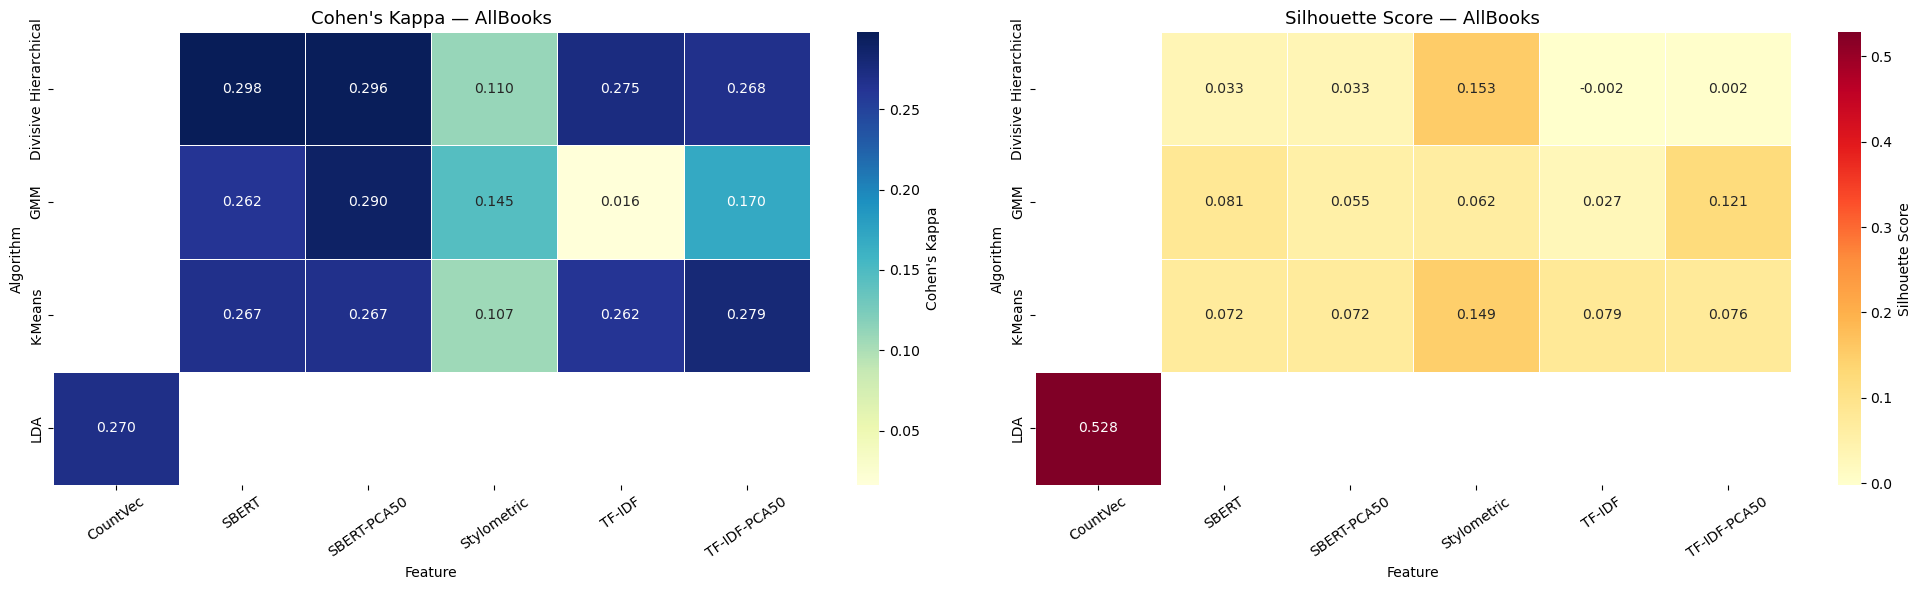

Saved: images/allbooks_evaluation_heatmap.png


In [ ]:
pivot_k = results_df.pivot_table(index='Algorithm', columns='Feature', values='Kappa',      aggfunc='max')
pivot_s = results_df.pivot_table(index='Algorithm', columns='Feature', values='Silhouette', aggfunc='max')

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.heatmap(pivot_k, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0],
            cbar_kws={'label': "Cohen's Kappa"}, linewidths=0.5)
axes[0].set_title("Cohen's Kappa — AllBooks", fontsize=13)
axes[0].tick_params(axis='x', rotation=35)

sns.heatmap(pivot_s, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': 'Silhouette Score'}, linewidths=0.5)
axes[1].set_title('Silhouette Score — AllBooks', fontsize=13)
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('images/allbooks_evaluation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/allbooks_evaluation_heatmap.png')

## Error Analysis
Confusion matrix and most-confused partitions for the best-performing model.

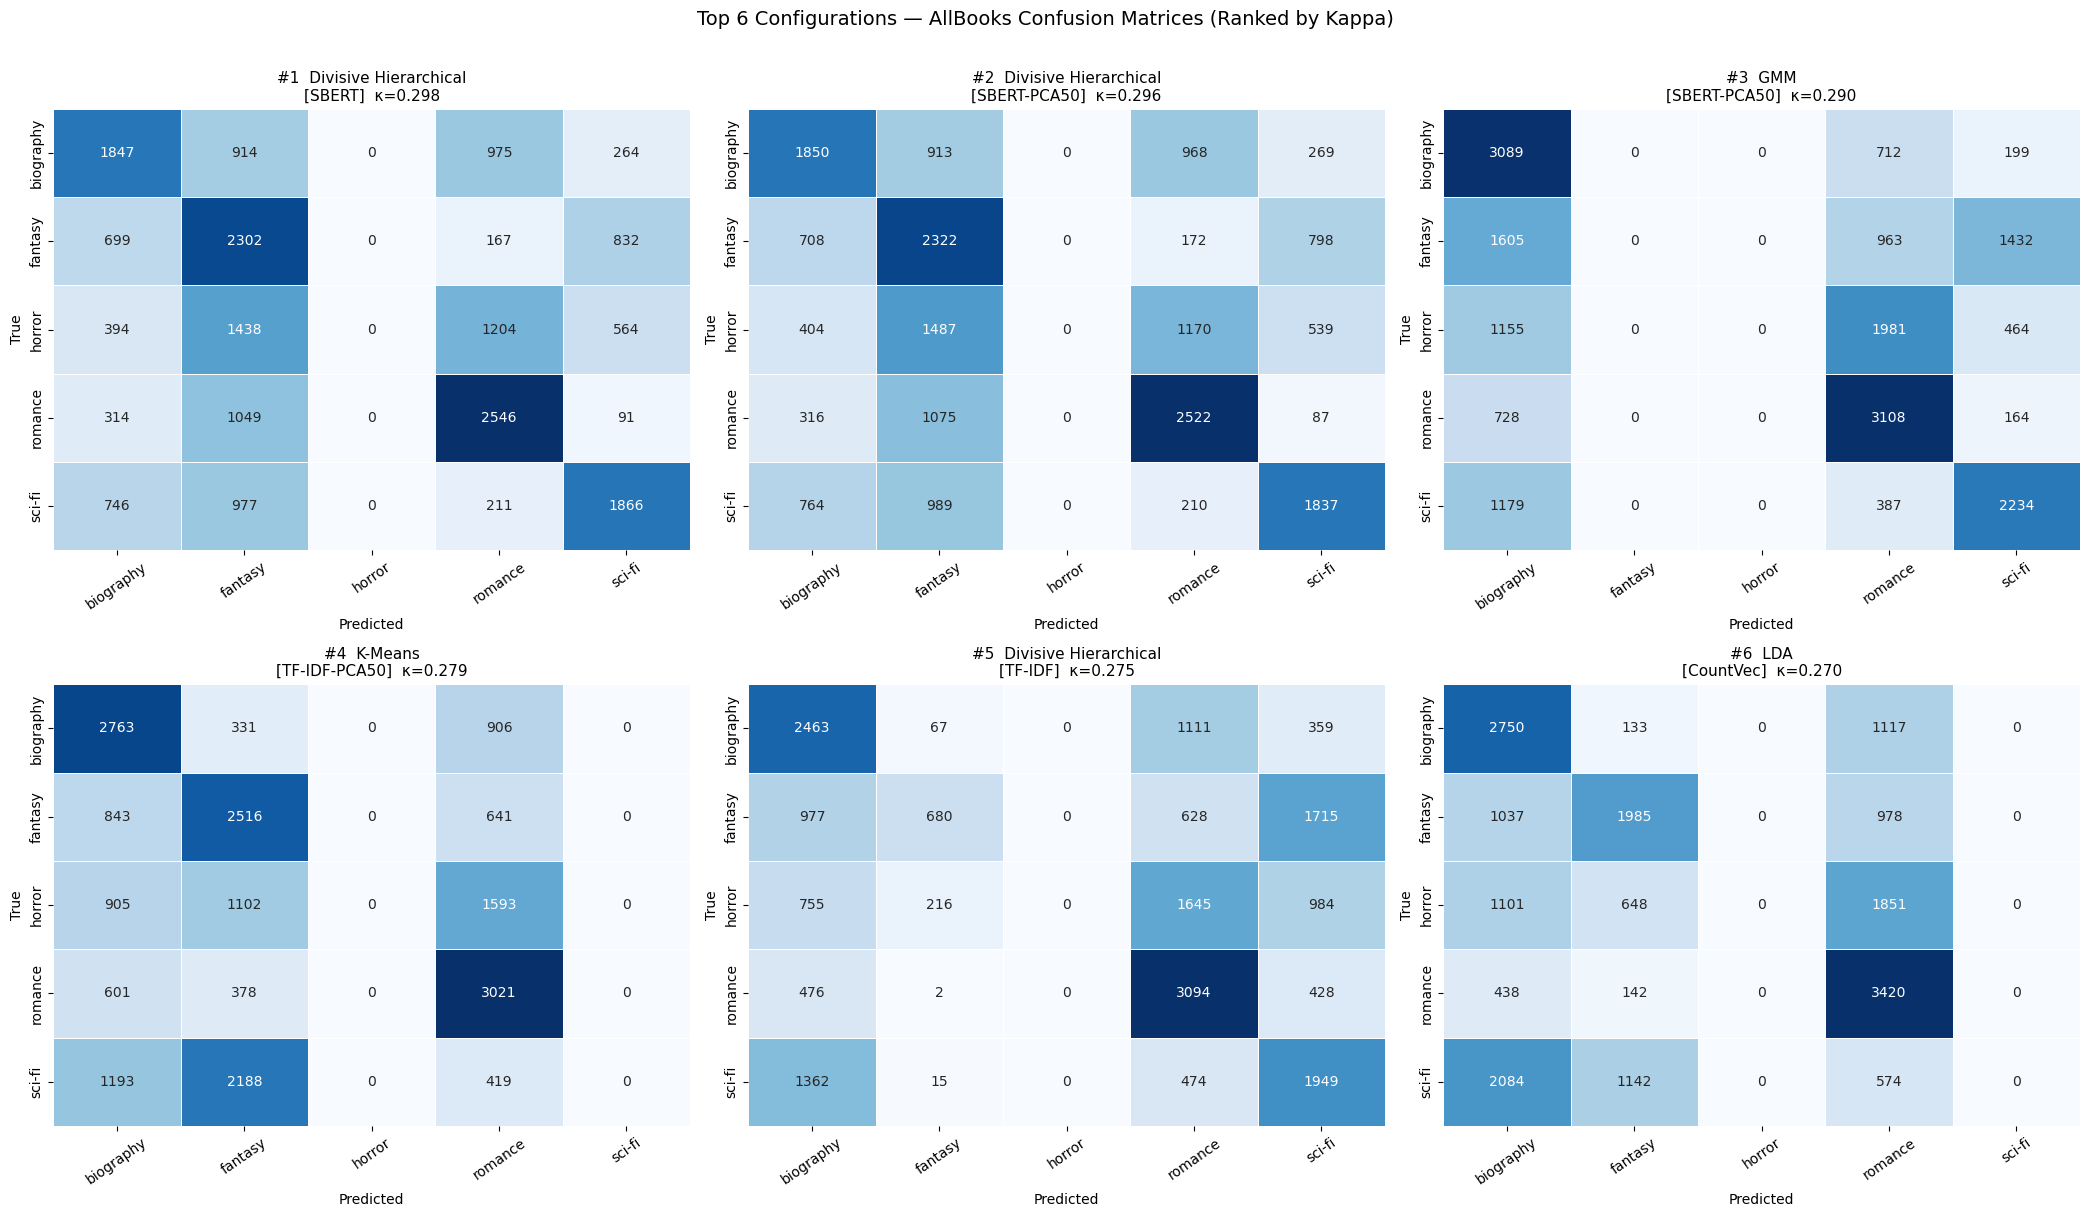

Saved: images/allbooks_top6_confusion.png

Champion: Divisive Hierarchical + SBERT


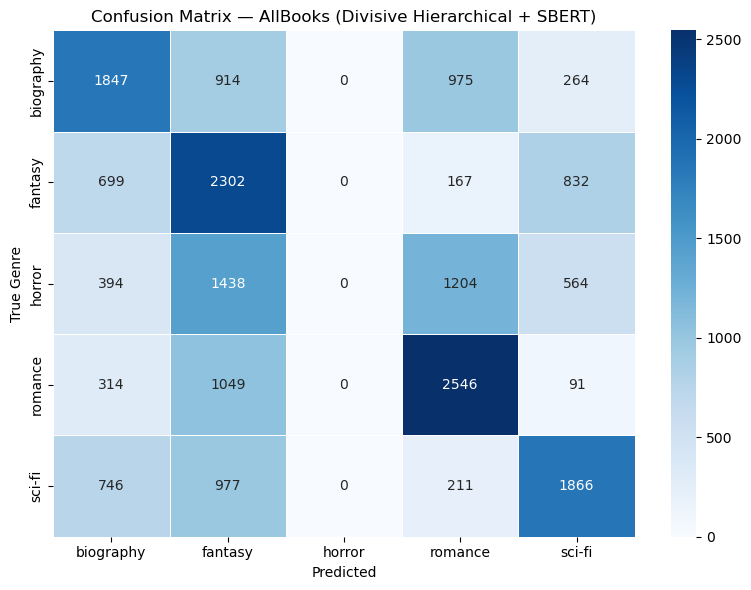

Saved: images/allbooks_confusion_matrix.png

Total misclassified: 10839/19400 (55.9%)

Per-genre error rate:
  biography   : 2153/4000 (53.8%)
  fantasy     : 1698/4000 (42.4%)
  horror      : 3600/3600 (100.0%)
  romance     : 1454/4000 (36.4%)
  sci-fi      : 1934/3800 (50.9%)

Top 10 confusion pairs:


,true,pred,count
7,horror,fantasy,1438
8,horror,romance,1204
11,romance,fantasy,1049
14,sci-fi,fantasy,977
1,biography,romance,975
0,biography,fantasy,914
5,fantasy,sci-fi,832
13,sci-fi,biography,746
3,fantasy,biography,699
9,horror,sci-fi,564


In [ ]:
from sklearn.metrics import confusion_matrix

orig_df = pd.DataFrame(all_results)
top6    = results_df.nlargest(6, 'Kappa').reset_index(drop=True)

# ── Top-6 confusion matrices (2 × 3 grid) ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(21, 12))
axes = axes.flatten()
for ax_idx, row in top6.iterrows():
    algo = row['Algorithm']
    feat = row['Feature']
    match    = orig_df.index[(orig_df['Algorithm'] == algo) &
                              (orig_df['Feature']   == feat)].tolist()
    pred_idx  = match[0] if match else 0
    _, mapped = all_preds[pred_idx]
    cm = confusion_matrix(y_true, mapped, labels=GENRES)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=GENRES, yticklabels=GENRES,
                ax=axes[ax_idx], linewidths=0.4, cbar=False)
    axes[ax_idx].set_title(f'#{ax_idx+1}  {algo}\n[{feat}]  κ={row["Kappa"]:.3f}', fontsize=11)
    axes[ax_idx].set_xlabel('Predicted')
    axes[ax_idx].set_ylabel('True')
    axes[ax_idx].tick_params(axis='x', rotation=35)
plt.suptitle('Top 6 Configurations — AllBooks Confusion Matrices (Ranked by Kappa)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('images/allbooks_top6_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/allbooks_top6_confusion.png')

# ── Champion confusion matrix (full-size) ────────────────────────────────
best_algo = results_df.loc[results_df['Kappa'].idxmax(), 'Algorithm']
best_feat = results_df.loc[results_df['Kappa'].idxmax(), 'Feature']
match     = orig_df.index[(orig_df['Algorithm'] == best_algo) &
                           (orig_df['Feature']   == best_feat)].tolist()
champ_pos = match[0] if match else 0
y_pred_best, mapped_best = all_preds[champ_pos]

print(f'\nChampion: {best_algo} + {best_feat}')
cm = confusion_matrix(y_true, mapped_best, labels=GENRES)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES, ax=ax, linewidths=0.5)
ax.set_title(f'Confusion Matrix — AllBooks ({best_algo} + {best_feat})')
ax.set_xlabel('Predicted')
ax.set_ylabel('True Genre')
plt.tight_layout()
plt.savefig('images/allbooks_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/allbooks_confusion_matrix.png')

# ── Error statistics ──────────────────────────────────────────────────────
err_df = pd.DataFrame({'partition_id': part_ids, 'text': X_text,
                        'true': y_true, 'pred': list(mapped_best)})
errors = err_df[err_df['true'] != err_df['pred']]
print(f'\nTotal misclassified: {len(errors)}/{len(df)} ({len(errors)/len(df):.1%})')
print('\nPer-genre error rate:')
for g in GENRES:
    tot = (err_df['true'] == g).sum()
    err = ((err_df['true'] == g) & (err_df['true'] != err_df['pred'])).sum()
    print(f'  {g:12}: {err}/{tot} ({err/max(tot,1):.1%})')
print('\nTop 10 confusion pairs:')
pairs = (errors.groupby(['true', 'pred'])
               .size().reset_index(name='count')
               .sort_values('count', ascending=False))
display(pairs.head(10))

In [ ]:
print('Sample misclassified partitions (2 per genre):')
for g in GENRES:
    subset = errors[errors['true'] == g].head(2)
    if subset.empty: continue
    print(f'\n  [{g.upper()}]')
    for _, row in subset.iterrows():
        print(f'    Predicted : {row["pred"]}')
        print(f'    ID        : {row["partition_id"]}')
        print(f'    Snippet   : {row["text"][:200]}...')

Sample misclassified partitions (2 per genre):

  [BIOGRAPHY]
    Predicted : romance
    ID        : 10378_part_004
    Snippet   : of Court who joined in it, I remember Charles Villiers. The other side obtained also, on the population question, very efficient support from without. The well-known Gale Jones, then an elderly man, m...
    Predicted : romance
    ID        : 10378_part_007
    Snippet   : strike out the words which were understood to limit the electoral franchise to males, and thereby to admit to the suffrage all women who, as householders or otherwise, possessed the qualification requ...

  [FANTASY]
    Predicted : sci-fi
    ID        : 10662_part_001
    Snippet   : I go thus, and came at last to a place where a fire-hole did shine more ruddy; and I did look well about me, that I should perceive that part of the Gorge the better. And as I stood there, very quiet,...
    Predicted : sci-fi
    ID        : 10662_part_002
    Snippet   : I did go downward of the great 

In [ ]:
GENRE_PALETTE = {
    'biography': '#e41a1c',
    'fantasy':   '#377eb8',
    'horror':    '#4daf4a',
    'romance':   '#984ea3',
    'sci-fi':    '#ff7f00',
    'unknown':   '#aaaaaa',
}

_feat_map = {
    'TF-IDF':       X_tfidf_dense,
    'TF-IDF-PCA50': X_tfidf_pca,
    'Stylometric':  X_stylo,
    'CountVec':     X_lda_probs,
    'BOW':          X_bow      if X_bow  is not None else X_tfidf_pca,
    'LMF':          X_lmf      if X_lmf  is not None else X_stylo,
    'Stylo+LMF':    (np.hstack([X_stylo, X_lmf]) if X_lmf is not None else X_stylo),
    'SBERT':        X_sbert    if X_sbert is not None else X_tfidf_pca,
    'SBERT-PCA50':  X_sbert_pca,
}

orig_df    = pd.DataFrame(all_results)
top6       = results_df.nlargest(6, 'Kappa').reset_index(drop=True)
y_true_arr = np.array(y_true)

fig, axes = plt.subplots(6, 2, figsize=(14, 30))

for row_idx, (_, row) in enumerate(top6.iterrows()):
    algo  = row['Algorithm']
    feat  = row['Feature']
    kappa = row['Kappa']

    match    = orig_df.index[(orig_df['Algorithm'] == algo) &
                              (orig_df['Feature']   == feat)].tolist()
    pred_idx  = match[0] if match else 0
    _, mapped = all_preds[pred_idx]
    mapped    = np.array(mapped)

    X_feat = _feat_map.get(feat, X_tfidf_pca)
    X2d    = (PCA(n_components=2, random_state=42).fit_transform(X_feat)
              if X_feat.shape[1] > 2 else X_feat)

    ax_true = axes[row_idx, 0]
    ax_pred = axes[row_idx, 1]

    for genre, colour in GENRE_PALETTE.items():
        mask = y_true_arr == genre
        if not mask.any(): continue
        ax_true.scatter(X2d[mask, 0], X2d[mask, 1],
                        c=colour, label=genre, s=4, alpha=0.35, linewidths=0)
    ax_true.set_title(f'#{row_idx+1}: {algo} [{feat}]\nTrue Genre', fontsize=10)
    ax_true.legend(markerscale=3, fontsize=7, loc='best')
    ax_true.set_xticks([]); ax_true.set_yticks([])

    for label in sorted(set(mapped)):
        colour = GENRE_PALETTE.get(label, '#aaaaaa')
        mask = mapped == label
        ax_pred.scatter(X2d[mask, 0], X2d[mask, 1],
                        c=colour, label=label, s=4, alpha=0.35, linewidths=0)
    ax_pred.set_title(f'#{row_idx+1}: {algo} [{feat}]  κ={kappa:.3f}\nPredicted', fontsize=10)
    ax_pred.legend(markerscale=3, fontsize=7, loc='best')
    ax_pred.set_xticks([]); ax_pred.set_yticks([])

plt.suptitle('Top 6 Configurations — AllBooks PCA 2D Cluster Plots (True Genre vs Predicted)',
             fontsize=13, y=1.002)
plt.tight_layout()
plt.savefig('images/allbooks_top6_cluster_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/allbooks_top6_cluster_plots.png')

## Top 20 Frequent Words and Collocations per Cluster

In [ ]:
mapped_arr = np.array(mapped_best)
print('Top 20 words / collocations per cluster\n')
for genre_name in GENRES:
    mask = mapped_arr == genre_name
    if not mask.any():
        print(f'[{genre_name}] — no samples\n')
        continue
    texts_c = [X_text[i] for i in range(len(X_text)) if mask[i]]
    cv_t    = CountVectorizer(stop_words='english', ngram_range=(1, 2),
                              max_features=20000, min_df=1)
    X_t     = cv_t.fit_transform(texts_c)
    vocab_t = cv_t.get_feature_names_out()
    freq_t  = np.asarray(X_t.sum(axis=0)).flatten()
    top20   = freq_t.argsort()[::-1][:20]
    true_cnts = Counter(np.array(y_true)[mask])
    purity    = true_cnts.most_common(1)[0][1] / mask.sum()
    dominant  = true_cnts.most_common(1)[0][0]
    print(f'Cluster -> "{genre_name.upper()}"  ({mask.sum()} partitions, '
          f'purity={purity:.1%}, dominant true genre="{dominant}")')
    term_df = pd.DataFrame([(vocab_t[i], int(freq_t[i])) for i in top20],
                           columns=['term', 'count'])
    term_df.index += 1
    display(term_df)
    print()

Top 20 words / collocations per cluster

Cluster -> "BIOGRAPHY"  (4000 partitions, purity=46.2%, dominant true genre="biography")


,term,count
1,ja,4692
2,shall,4565
3,hän,3658
4,man,2845
5,time,2649
6,oli,2481
7,said,2397
8,ei,2243
9,states,2100
10,state,2071



Cluster -> "FANTASY"  (6680 partitions, purity=34.5%, dominant true genre="fantasy")


,term,count
1,said,12819
2,did,6113
3,little,5843
4,like,5159
5,man,5051
6,time,4661
7,know,4291
8,came,4026
9,come,3671
10,shall,3566



[horror] — no samples

Cluster -> "ROMANCE"  (5103 partitions, purity=49.9%, dominant true genre="romance")


,term,count
1,said,8635
2,mr,5735
3,little,4252
4,did,4044
5,mrs,3896
6,know,3886
7,man,3691
8,time,3677
9,good,3495
10,like,3254



Cluster -> "SCI-FI"  (3617 partitions, purity=51.6%, dominant true genre="sci-fi")


,term,count
1,said,3244
2,did,3050
3,like,2827
4,great,2565
5,time,2563
6,little,2327
7,came,2227
8,man,2197
9,saw,1928
10,way,1769
